<a href="https://colab.research.google.com/github/hudayaranjit/IIITK-Internship/blob/main/Uday.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Loaded Successfully
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  

Shape : (303, 14)

Missing Values
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


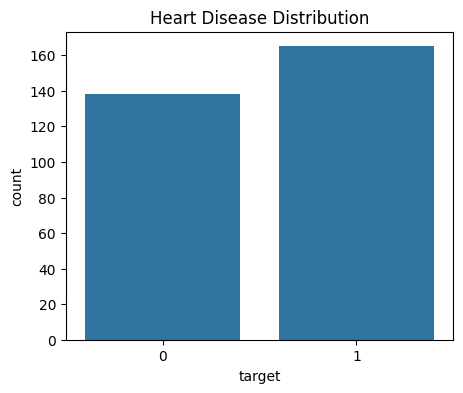

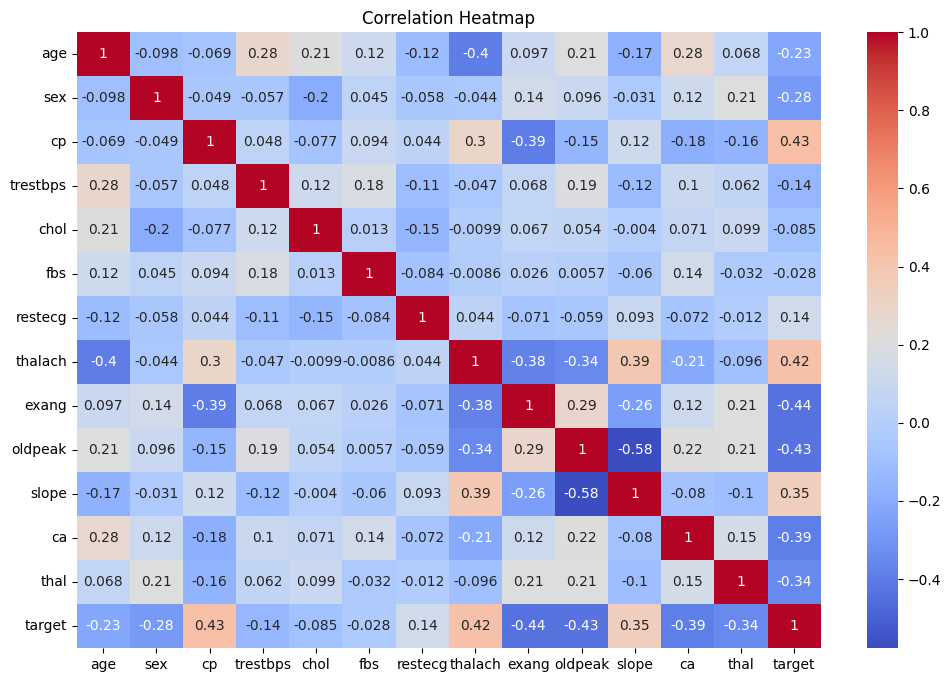


MODEL PERFORMANCE

                    Model  Accuracy  Precision   Recall  F1 Score
0     Logistic Regression  0.852459   0.870968  0.84375  0.857143
1           Decision Tree  0.754098   0.840000  0.65625  0.736842
2           Random Forest  0.836066   0.843750  0.84375  0.843750
3  Support Vector Machine  0.868852   0.900000  0.84375  0.870968


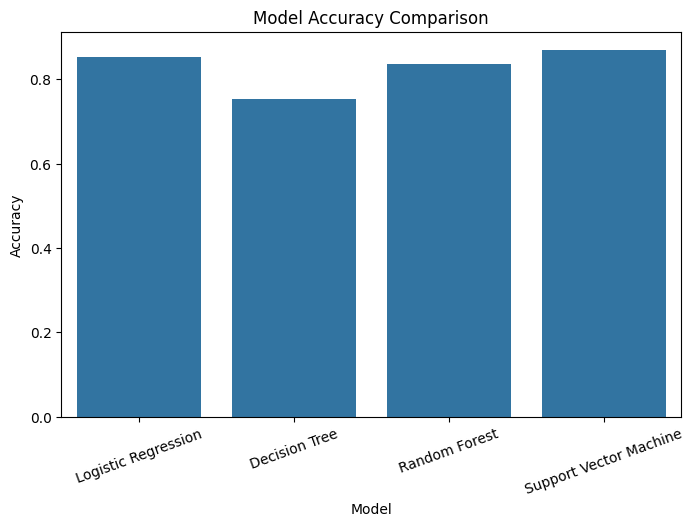

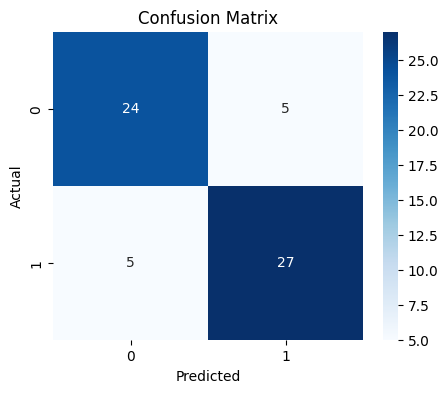


Classification Report

              precision    recall  f1-score   support

           0       0.83      0.83      0.83        29
           1       0.84      0.84      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



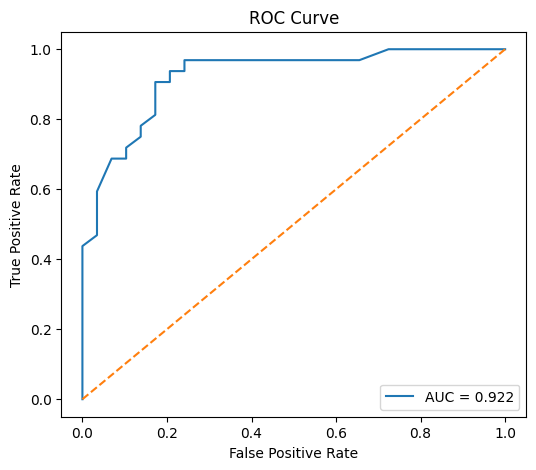

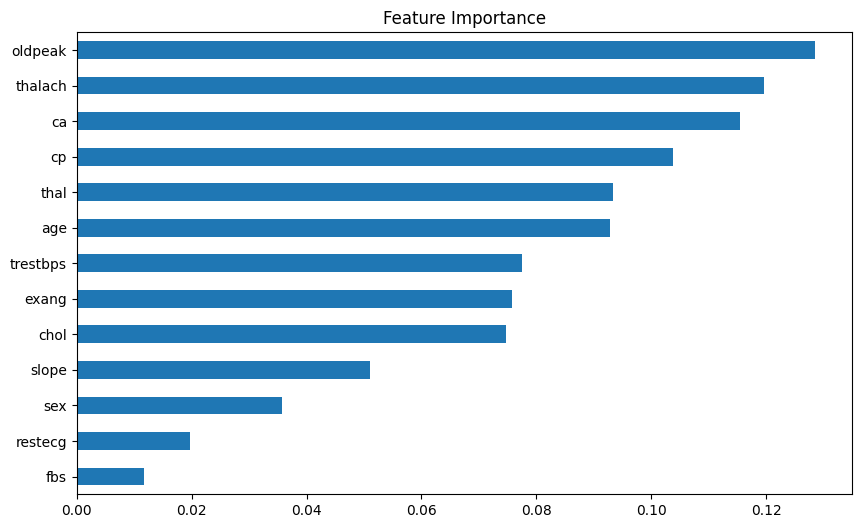


Prediction Result
Heart Disease Detected

Project Completed Successfully


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# ==========================================================
# UDAY PAPER 1
# Effective Heart Disease Prediction Using Machine Learning
# Single Google Colab Code (No Dataset Upload Required)
# ==========================================================

!pip -q install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

# ------------------------------------------------------------
# Download Dataset Automatically
# ------------------------------------------------------------

url = "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"

df = pd.read_csv(url)

print("Dataset Loaded Successfully")
print(df.head())

# ------------------------------------------------------------
# Dataset Information
# ------------------------------------------------------------

print("\nShape :", df.shape)
print("\nMissing Values")
print(df.isnull().sum())

# ------------------------------------------------------------
# Target Distribution
# ------------------------------------------------------------

plt.figure(figsize=(5,4))
sns.countplot(data=df,x="target")
plt.title("Heart Disease Distribution")
plt.show()

# ------------------------------------------------------------
# Correlation Matrix
# ------------------------------------------------------------

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# ------------------------------------------------------------
# Features and Target
# ------------------------------------------------------------

X=df.drop("target",axis=1)
y=df["target"]

# ------------------------------------------------------------
# Split Data
# ------------------------------------------------------------

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ------------------------------------------------------------
# Standardization
# ------------------------------------------------------------

scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

# ------------------------------------------------------------
# Models
# ------------------------------------------------------------

models={
    "Logistic Regression":LogisticRegression(max_iter=1000),
    "Decision Tree":DecisionTreeClassifier(random_state=42),
    "Random Forest":RandomForestClassifier(random_state=42),
    "Support Vector Machine":SVC(probability=True)
}

results=[]

print("\nMODEL PERFORMANCE\n")

for name,model in models.items():

    model.fit(X_train,y_train)

    pred=model.predict(X_test)

    acc=accuracy_score(y_test,pred)
    pre=precision_score(y_test,pred)
    rec=recall_score(y_test,pred)
    f1=f1_score(y_test,pred)

    results.append([name,acc,pre,rec,f1])

results=pd.DataFrame(results,
                     columns=[
                         "Model",
                         "Accuracy",
                         "Precision",
                         "Recall",
                         "F1 Score"
                     ])

print(results)

# ------------------------------------------------------------
# Accuracy Graph
# ------------------------------------------------------------

plt.figure(figsize=(8,5))
sns.barplot(data=results,x="Model",y="Accuracy")
plt.xticks(rotation=20)
plt.title("Model Accuracy Comparison")
plt.show()

# ------------------------------------------------------------
# Best Model (Random Forest)
# ------------------------------------------------------------

rf=RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

prediction=rf.predict(X_test)

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm=confusion_matrix(y_test,prediction)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print("\nClassification Report\n")

print(classification_report(y_test,prediction))

# ------------------------------------------------------------
# ROC Curve
# ------------------------------------------------------------

prob=rf.predict_proba(X_test)[:,1]

fpr,tpr,_=roc_curve(y_test,prob)

roc_auc=auc(fpr,tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr,tpr,label="AUC = %.3f"%roc_auc)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

# ------------------------------------------------------------
# Feature Importance
# ------------------------------------------------------------

importance=pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Feature Importance")
plt.show()

# ------------------------------------------------------------
# New Patient Prediction
# ------------------------------------------------------------

sample=np.array([[63,1,3,145,233,1,0,150,0,2.3,0,0,1]])

sample=scaler.transform(sample)

result=rf.predict(sample)

print("\nPrediction Result")

if result[0]==1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease")

print("\nProject Completed Successfully")

Dataset Loaded Successfully

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  

Dataset Shape : (303, 14)

Missing Values
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Statistical Summary
              age         sex          cp    trestbps        chol         fbs  

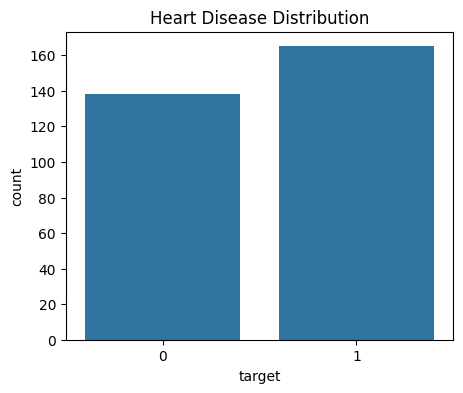

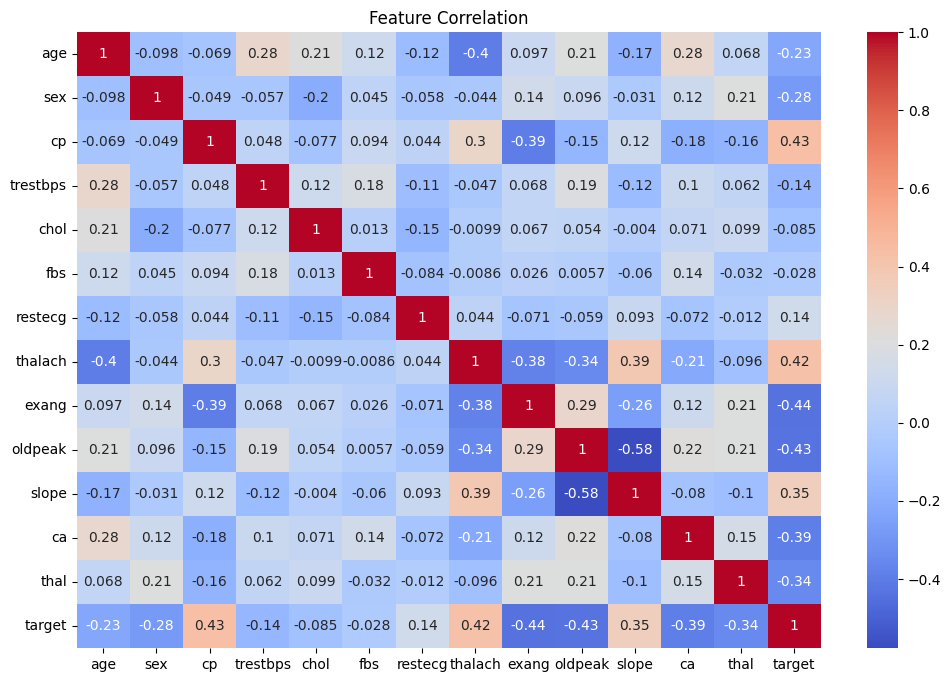


MODEL COMPARISON

                    Model  Accuracy  Precision    Recall  F1 Score
0     Logistic Regression  0.803279   0.769231  0.909091  0.833333
1           Decision Tree  0.704918   0.702703  0.787879  0.742857
2  Support Vector Machine  0.819672   0.775000  0.939394  0.849315
3           Random Forest  0.819672   0.761905  0.969697  0.853333


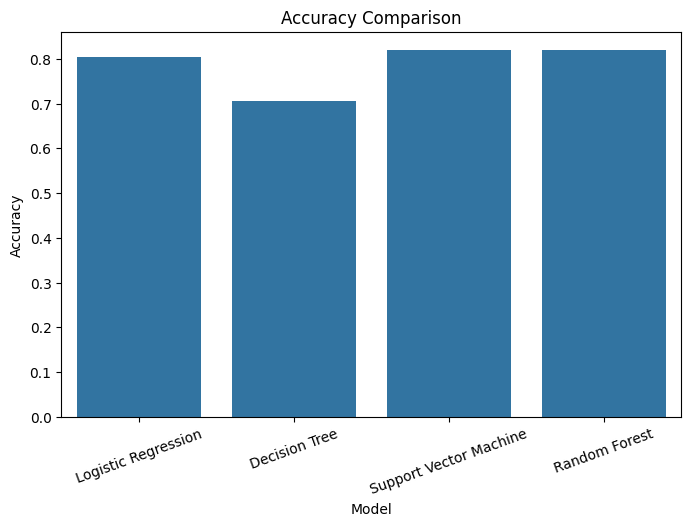

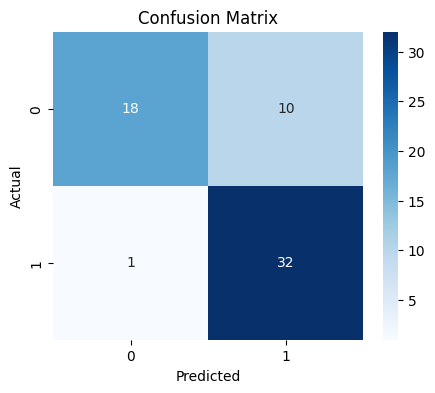


Classification Report

              precision    recall  f1-score   support

           0       0.95      0.64      0.77        28
           1       0.76      0.97      0.85        33

    accuracy                           0.82        61
   macro avg       0.85      0.81      0.81        61
weighted avg       0.85      0.82      0.81        61



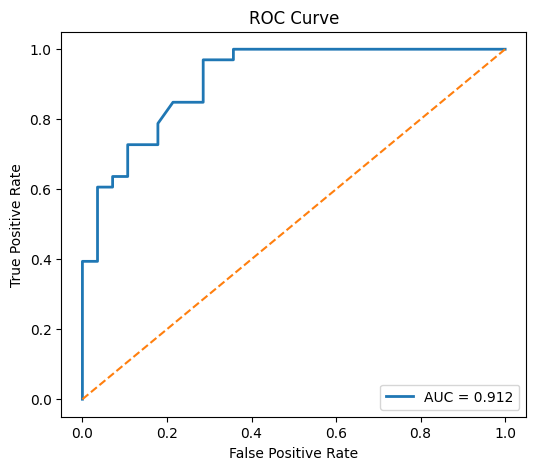

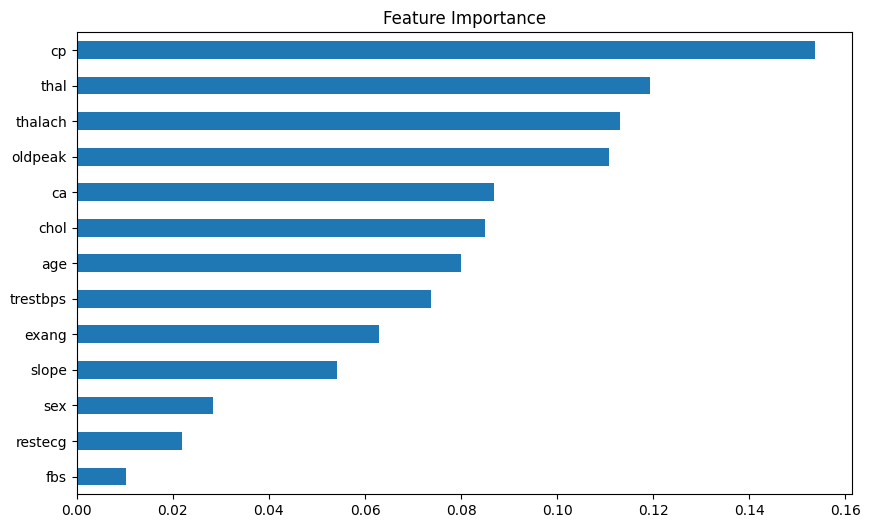


Prediction Result
Heart Disease Detected

Overall Accuracy : 81.97 %

PROJECT COMPLETED SUCCESSFULLY


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# ===============================================================
# UDAY PAPER 2
# Effective Heart Disease Prediction Using Machine Learning
# Comparative Analysis of DT, LR, SVM and RF
# ===============================================================

!pip -q install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import *

# ---------------------------------------------------------
# Load Dataset Automatically
# ---------------------------------------------------------

url="https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"

df=pd.read_csv(url)

print("Dataset Loaded Successfully\n")

print(df.head())

# ---------------------------------------------------------
# Basic Information
# ---------------------------------------------------------

print("\nDataset Shape :",df.shape)

print("\nMissing Values")

print(df.isnull().sum())

print("\nStatistical Summary")

print(df.describe())

# ---------------------------------------------------------
# Class Distribution
# ---------------------------------------------------------

plt.figure(figsize=(5,4))

sns.countplot(data=df,x="target")

plt.title("Heart Disease Distribution")

plt.show()

# ---------------------------------------------------------
# Correlation Matrix
# ---------------------------------------------------------

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Feature Correlation")

plt.show()

# ---------------------------------------------------------
# Feature Selection
# ---------------------------------------------------------

X=df.drop("target",axis=1)

y=df["target"]

# ---------------------------------------------------------
# Train Test Split
# ---------------------------------------------------------

X_train,X_test,y_train,y_test=train_test_split(

X,
y,

test_size=0.20,

random_state=42,

stratify=y

)

# ---------------------------------------------------------
# Feature Scaling
# ---------------------------------------------------------

scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)

X_test=scaler.transform(X_test)

# ---------------------------------------------------------
# Machine Learning Models
# ---------------------------------------------------------

models={

"Logistic Regression":LogisticRegression(max_iter=1000),

"Decision Tree":DecisionTreeClassifier(random_state=42),

"Support Vector Machine":SVC(probability=True),

"Random Forest":RandomForestClassifier(n_estimators=200,
                                       random_state=42)

}

results=[]

print("\nMODEL COMPARISON\n")

for name,model in models.items():

    model.fit(X_train,y_train)

    pred=model.predict(X_test)

    acc=accuracy_score(y_test,pred)

    pre=precision_score(y_test,pred)

    rec=recall_score(y_test,pred)

    f1=f1_score(y_test,pred)

    results.append([name,acc,pre,rec,f1])

results=pd.DataFrame(results,

columns=[

"Model",

"Accuracy",

"Precision",

"Recall",

"F1 Score"

])

print(results)

# ---------------------------------------------------------
# Accuracy Comparison
# ---------------------------------------------------------

plt.figure(figsize=(8,5))

sns.barplot(

data=results,

x="Model",

y="Accuracy"

)

plt.xticks(rotation=20)

plt.title("Accuracy Comparison")

plt.show()

# ---------------------------------------------------------
# Best Model
# ---------------------------------------------------------

best_model=RandomForestClassifier(

n_estimators=200,

random_state=42

)

best_model.fit(X_train,y_train)

prediction=best_model.predict(X_test)

# ---------------------------------------------------------
# Confusion Matrix
# ---------------------------------------------------------

cm=confusion_matrix(y_test,prediction)

plt.figure(figsize=(5,4))

sns.heatmap(cm,

annot=True,

fmt="d",

cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

# ---------------------------------------------------------
# Classification Report
# ---------------------------------------------------------

print("\nClassification Report\n")

print(classification_report(

y_test,

prediction

))

# ---------------------------------------------------------
# ROC Curve
# ---------------------------------------------------------

prob=best_model.predict_proba(X_test)[:,1]

fpr,tpr,_=roc_curve(y_test,prob)

roc_auc=auc(fpr,tpr)

plt.figure(figsize=(6,5))

plt.plot(

fpr,

tpr,

label="AUC = %.3f"%roc_auc,

linewidth=2

)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# ---------------------------------------------------------
# Feature Importance
# ---------------------------------------------------------

importance=pd.Series(

best_model.feature_importances_,

index=X.columns

)

importance=importance.sort_values()

plt.figure(figsize=(10,6))

importance.plot(kind="barh")

plt.title("Feature Importance")

plt.show()

# ---------------------------------------------------------
# New Patient Prediction
# ---------------------------------------------------------

patient=np.array([[52,

1,

2,

130,

220,

0,

1,

160,

0,

1.2,

2,

0,

2]])

patient=scaler.transform(patient)

result=best_model.predict(patient)

print("\nPrediction Result")

if result[0]==1:

    print("Heart Disease Detected")

else:

    print("No Heart Disease")

# ---------------------------------------------------------
# Final Accuracy
# ---------------------------------------------------------

print("\nOverall Accuracy :",

round(accuracy_score(y_test,prediction)*100,2),

"%")

print("\nPROJECT COMPLETED SUCCESSFULLY")

Dataset Loaded Successfully
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  
(303, 14)
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


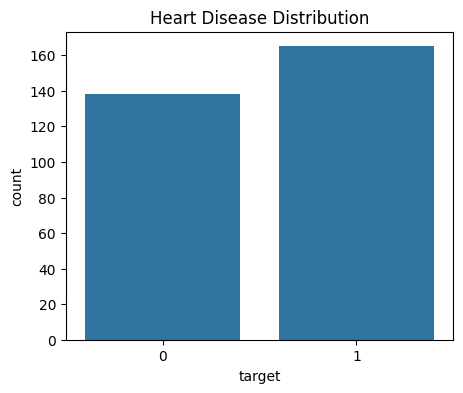

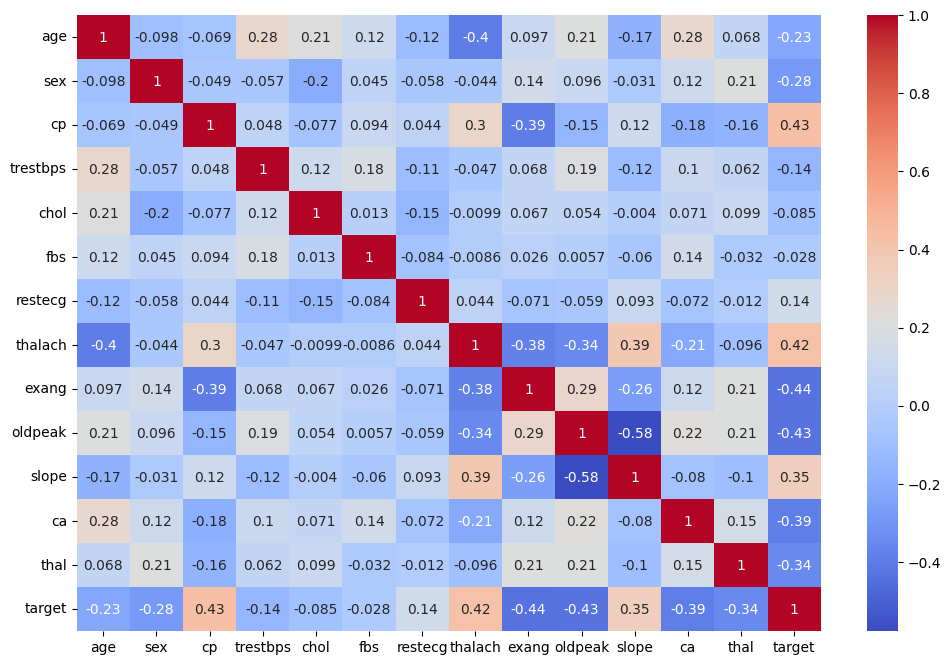

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.5544 - loss: 0.6809 - val_accuracy: 0.8571 - val_loss: 0.6084
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7409 - loss: 0.6236 - val_accuracy: 0.8367 - val_loss: 0.5517
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7358 - loss: 0.5646 - val_accuracy: 0.8571 - val_loss: 0.4643
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7772 - loss: 0.5194 - val_accuracy: 0.8367 - val_loss: 0.4260
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8083 - loss: 0.4721 - val_accuracy: 0.8571 - val_loss: 0.3767
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8238 - loss: 0.4239 - val_accuracy: 0.8571 - val_loss: 0.3534
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8187 - loss: 0.4221 - val_accuracy: 0.8571 - val_loss: 0.3443
Epoch 8/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8031 - loss: 0.4105 - val_accuracy: 0.8367 - val_loss: 0.3432
Ep

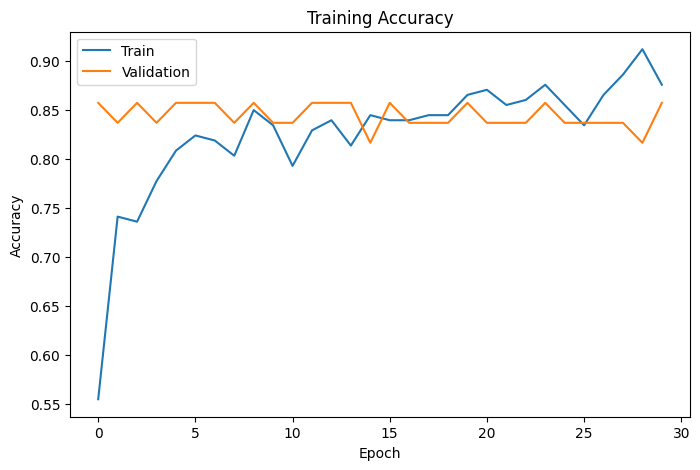

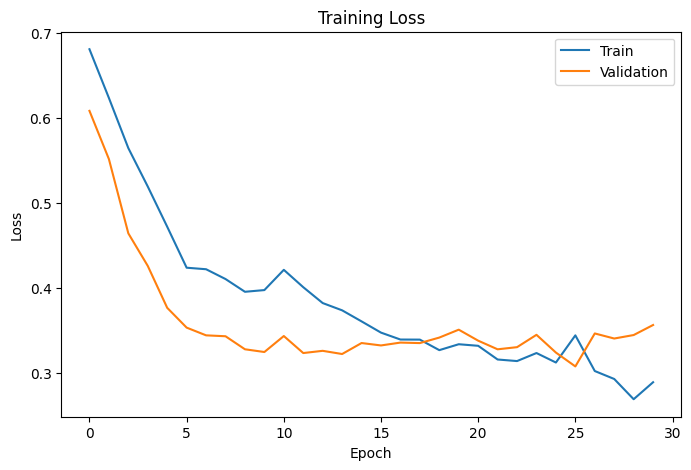

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Accuracy : 70.49 %
              precision    recall  f1-score   support

           0       0.71      0.61      0.65        28
           1       0.70      0.79      0.74        33

    accuracy                           0.70        61
   macro avg       0.71      0.70      0.70        61
weighted avg       0.71      0.70      0.70        61



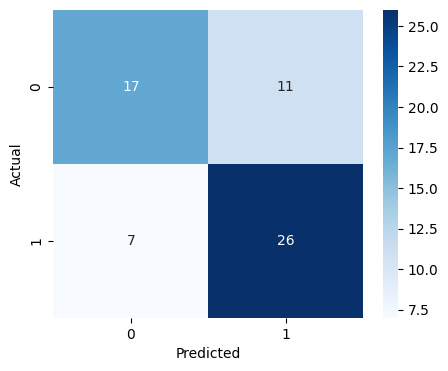

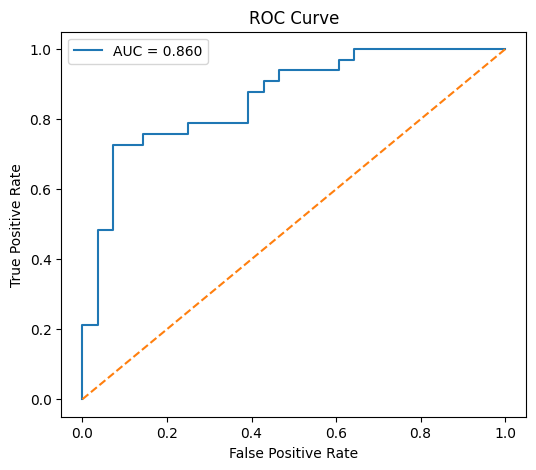

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

Prediction Result
Heart Disease Detected

CNN MODEL COMPLETED SUCCESSFULLY


In [ ]:
# ==========================================================
# UDAY PAPER 3
# An Efficient Convolutional Neural Network
# for Coronary Heart Disease Prediction
# ==========================================================

!pip -q install tensorflow pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import *

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

# ----------------------------------------------------
# Download Dataset Automatically
# ----------------------------------------------------

url="https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"

df=pd.read_csv(url)

print("Dataset Loaded Successfully")

print(df.head())

# ----------------------------------------------------
# Basic Information
# ----------------------------------------------------

print(df.shape)

print(df.isnull().sum())

# ----------------------------------------------------
# Distribution
# ----------------------------------------------------

plt.figure(figsize=(5,4))
sns.countplot(data=df,x="target")
plt.title("Heart Disease Distribution")
plt.show()

# ----------------------------------------------------
# Correlation
# ----------------------------------------------------

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.show()

# ----------------------------------------------------
# Features
# ----------------------------------------------------

X=df.drop("target",axis=1).values
y=df["target"].values

# ----------------------------------------------------
# Split
# ----------------------------------------------------

X_train,X_test,y_train,y_test=train_test_split(
X,
y,
test_size=0.2,
random_state=42,
stratify=y
)

# ----------------------------------------------------
# Standardization
# ----------------------------------------------------

scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

# ----------------------------------------------------
# CNN Input Shape
# ----------------------------------------------------

X_train=X_train.reshape(X_train.shape[0],X_train.shape[1],1)

X_test=X_test.reshape(X_test.shape[0],X_test.shape[1],1)

# ----------------------------------------------------
# CNN Model
# ----------------------------------------------------

model=Sequential()

model.add(
Conv1D(
32,
kernel_size=2,
activation='relu',
input_shape=(13,1)
)
)

model.add(MaxPooling1D(pool_size=2))

model.add(Flatten())

model.add(Dense(64,activation='relu'))

model.add(Dropout(0.3))

model.add(Dense(32,activation='relu'))

model.add(Dense(1,activation='sigmoid'))

# ----------------------------------------------------
# Compile
# ----------------------------------------------------

model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)

# ----------------------------------------------------
# Train
# ----------------------------------------------------

history=model.fit(
X_train,
y_train,
epochs=30,
batch_size=16,
validation_split=0.2,
verbose=1
)

# ----------------------------------------------------
# Accuracy Graph
# ----------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

# ----------------------------------------------------
# Loss Graph
# ----------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

# ----------------------------------------------------
# Prediction
# ----------------------------------------------------

prob=model.predict(X_test)

prediction=(prob>0.5).astype(int)

# ----------------------------------------------------
# Accuracy
# ----------------------------------------------------

acc=accuracy_score(y_test,prediction)

print("Accuracy :",round(acc*100,2),"%")

# ----------------------------------------------------
# Classification Report
# ----------------------------------------------------

print(classification_report(y_test,prediction))

# ----------------------------------------------------
# Confusion Matrix
# ----------------------------------------------------

cm=confusion_matrix(y_test,prediction)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
annot=True,
fmt="d",
cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ----------------------------------------------------
# ROC Curve
# ----------------------------------------------------

fpr,tpr,_=roc_curve(y_test,prob)

roc_auc=auc(fpr,tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr,tpr,
label="AUC = %.3f"%roc_auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# ----------------------------------------------------
# New Patient Prediction
# ----------------------------------------------------

sample=np.array([[63,
1,
3,
145,
233,
1,
0,
150,
0,
2.3,
0,
0,
1]])

sample=scaler.transform(sample)

sample=sample.reshape(1,13,1)

result=model.predict(sample)

print("\nPrediction Result")

if result[0][0]>0.5:
    print("Heart Disease Detected")
else:
    print("No Heart Disease")

print("\nCNN MODEL COMPLETED SUCCESSFULLY")

Dataset Loaded Successfully
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  

Dataset Shape : (303, 14)

Missing Values
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


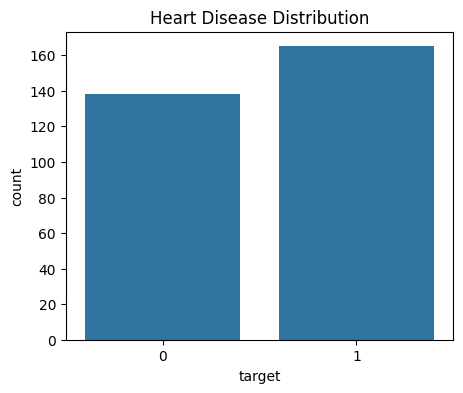

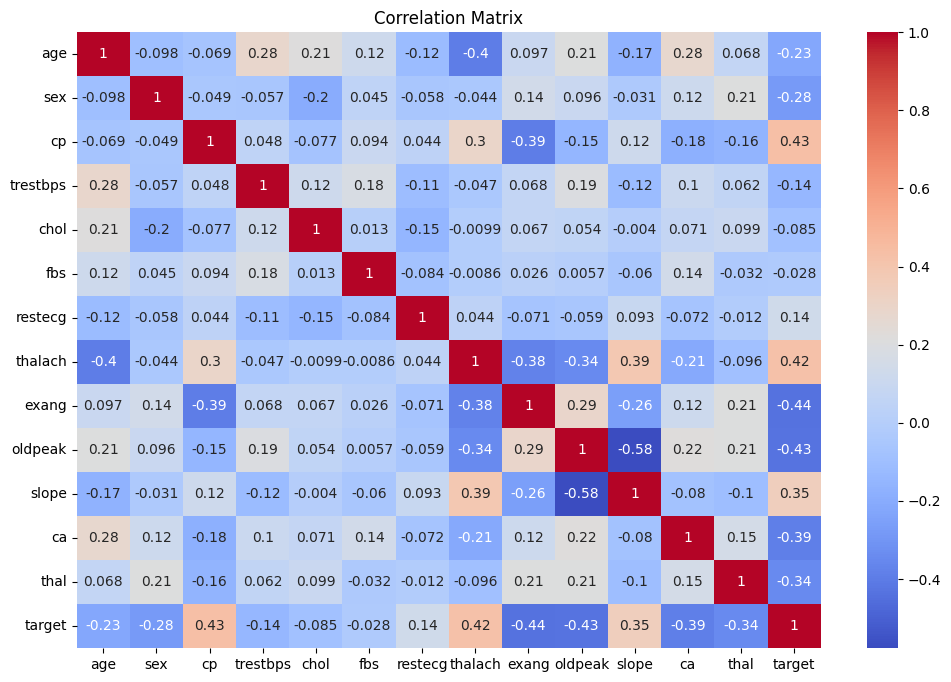


SUPPORT VECTOR MACHINE
Accuracy : 0.819672131147541
Precision : 0.775
Recall : 0.9393939393939394
F1 Score : 0.8493150684931506
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5233 - loss: 0.6873 - val_accuracy: 0.6735 - val_loss: 0.6589
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6528 - loss: 0.6591 - val_accuracy: 0.7551 - val_loss: 0.6243
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7202 - loss: 0.6250 - val_accuracy: 0.8367 - val_loss: 0.5888
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7876 - loss: 0.5780 - val_accuracy: 0.8367 - val_loss: 0.5492
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8031 - loss: 0.5565 - val_accuracy: 0.8367 - val_loss: 0.5102
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7876 - loss: 0.5283 - val_accuracy: 0.8367 - val_loss: 0.4808
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8083 - loss: 0.5101 - val_accuracy: 0.8367 - val_loss: 0.4533
Epoch 8/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8497 - loss: 0.4502 - val_accuracy: 0.8163 - val_loss: 0.4238
E

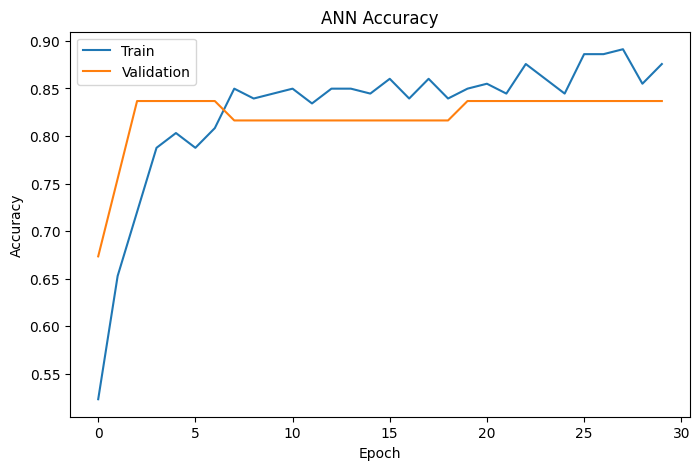

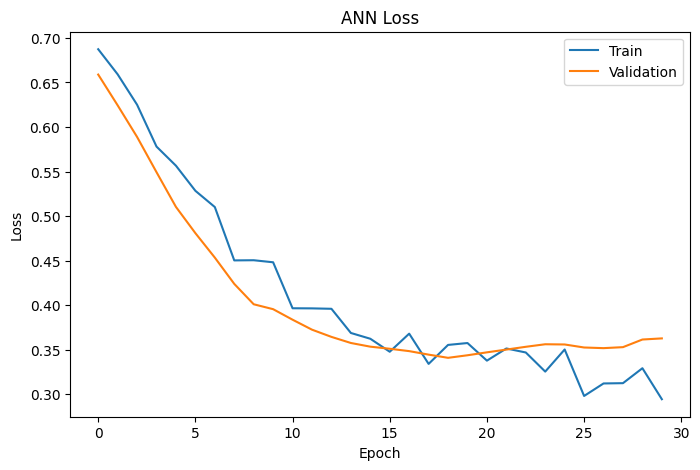

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

ARTIFICIAL NEURAL NETWORK
Accuracy : 0.7704918032786885
Precision : 0.7567567567567568
Recall : 0.8484848484848485
F1 Score : 0.8

MODEL COMPARISON

                       Model  Accuracy  Precision    Recall  F1 Score
0     Support Vector Machine  0.819672   0.775000  0.939394  0.849315
1  Artificial Neural Network  0.770492   0.756757  0.848485  0.800000


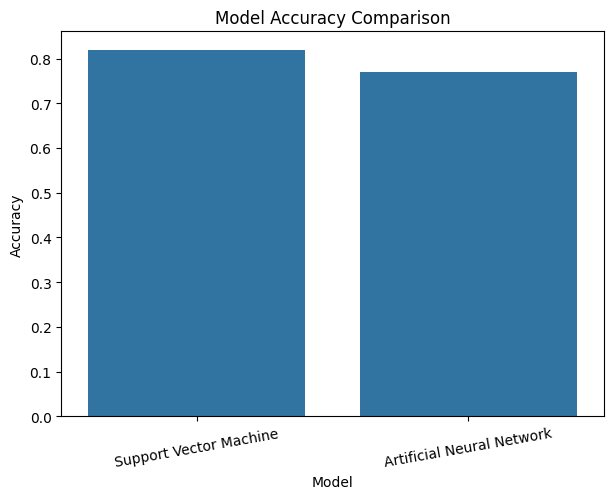

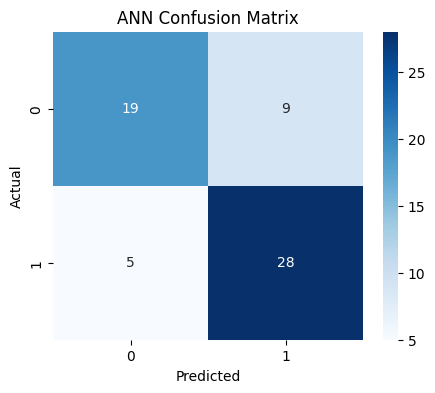


Classification Report

              precision    recall  f1-score   support

           0       0.79      0.68      0.73        28
           1       0.76      0.85      0.80        33

    accuracy                           0.77        61
   macro avg       0.77      0.76      0.77        61
weighted avg       0.77      0.77      0.77        61



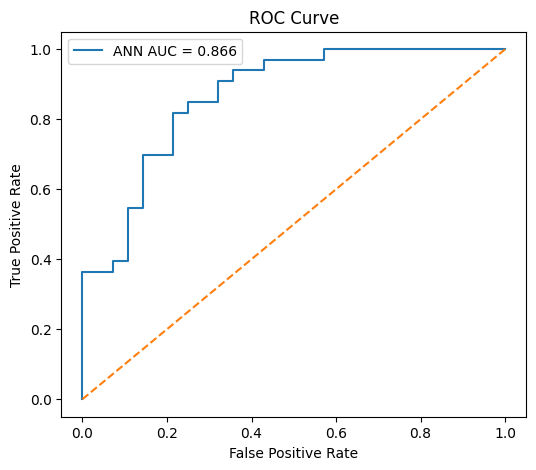

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

Prediction Result
Heart Disease Detected

PROJECT COMPLETED SUCCESSFULLY


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# ==========================================================
# UDAY PAPER 4
# Heart Disease Prediction using
# Support Vector Machine and Artificial Neural Network
# ==========================================================

!pip -q install tensorflow pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

# ----------------------------------------------------
# Load Dataset Automatically
# ----------------------------------------------------

url="https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"

df=pd.read_csv(url)

print("Dataset Loaded Successfully")

print(df.head())

print("\nDataset Shape :",df.shape)

print("\nMissing Values")

print(df.isnull().sum())

# ----------------------------------------------------
# Target Distribution
# ----------------------------------------------------

plt.figure(figsize=(5,4))

sns.countplot(data=df,x="target")

plt.title("Heart Disease Distribution")

plt.show()

# ----------------------------------------------------
# Correlation Heatmap
# ----------------------------------------------------

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),annot=True,cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

# ----------------------------------------------------
# Features
# ----------------------------------------------------

X=df.drop("target",axis=1)

y=df["target"]

# ----------------------------------------------------
# Split Dataset
# ----------------------------------------------------

X_train,X_test,y_train,y_test=train_test_split(
X,
y,
test_size=0.20,
random_state=42,
stratify=y
)

# ----------------------------------------------------
# Standardization
# ----------------------------------------------------

scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)

X_test=scaler.transform(X_test)

# ====================================================
# SUPPORT VECTOR MACHINE
# ====================================================

svm=SVC(
kernel="rbf",
probability=True,
random_state=42
)

svm.fit(X_train,y_train)

svm_pred=svm.predict(X_test)

print("\n==============================")
print("SUPPORT VECTOR MACHINE")
print("==============================")

print("Accuracy :",accuracy_score(y_test,svm_pred))

print("Precision :",precision_score(y_test,svm_pred))

print("Recall :",recall_score(y_test,svm_pred))

print("F1 Score :",f1_score(y_test,svm_pred))

# ====================================================
# ARTIFICIAL NEURAL NETWORK
# ====================================================

ann=Sequential()

ann.add(Dense(
32,
activation="relu",
input_shape=(13,)
))

ann.add(Dropout(0.3))

ann.add(Dense(
16,
activation="relu"
))

ann.add(Dense(
8,
activation="relu"
))

ann.add(Dense(
1,
activation="sigmoid"
))

ann.compile(
optimizer="adam",
loss="binary_crossentropy",
metrics=["accuracy"]
)

history=ann.fit(
X_train,
y_train,
epochs=30,
batch_size=16,
validation_split=0.2,
verbose=1
)

# ----------------------------------------------------
# ANN Accuracy Graph
# ----------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.title("ANN Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

# ----------------------------------------------------
# ANN Loss Graph
# ----------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.title("ANN Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

# ----------------------------------------------------
# ANN Prediction
# ----------------------------------------------------

prob=ann.predict(X_test)

ann_pred=(prob>0.5).astype(int)

print("\n==============================")
print("ARTIFICIAL NEURAL NETWORK")
print("==============================")

print("Accuracy :",accuracy_score(y_test,ann_pred))

print("Precision :",precision_score(y_test,ann_pred))

print("Recall :",recall_score(y_test,ann_pred))

print("F1 Score :",f1_score(y_test,ann_pred))

# ----------------------------------------------------
# Comparison
# ----------------------------------------------------

comparison=pd.DataFrame({

"Model":["Support Vector Machine","Artificial Neural Network"],

"Accuracy":[
accuracy_score(y_test,svm_pred),
accuracy_score(y_test,ann_pred)
],

"Precision":[
precision_score(y_test,svm_pred),
precision_score(y_test,ann_pred)
],

"Recall":[
recall_score(y_test,svm_pred),
recall_score(y_test,ann_pred)
],

"F1 Score":[
f1_score(y_test,svm_pred),
f1_score(y_test,ann_pred)
]

})

print("\nMODEL COMPARISON\n")

print(comparison)

# ----------------------------------------------------
# Accuracy Comparison Graph
# ----------------------------------------------------

plt.figure(figsize=(7,5))

sns.barplot(data=comparison,
            x="Model",
            y="Accuracy")

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=10)

plt.show()

# ----------------------------------------------------
# Confusion Matrix (ANN)
# ----------------------------------------------------

cm=confusion_matrix(y_test,ann_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
annot=True,
fmt="d",
cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("ANN Confusion Matrix")

plt.show()

# ----------------------------------------------------
# Classification Report
# ----------------------------------------------------

print("\nClassification Report\n")

print(classification_report(
y_test,
ann_pred
))

# ----------------------------------------------------
# ROC Curve
# ----------------------------------------------------

fpr,tpr,_=roc_curve(y_test,prob)

roc_auc=auc(fpr,tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr,
tpr,
label="ANN AUC = %.3f"%roc_auc)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# ----------------------------------------------------
# Predict New Patient
# ----------------------------------------------------

sample=np.array([[63,
1,
3,
145,
233,
1,
0,
150,
0,
2.3,
0,
0,
1]])

sample=scaler.transform(sample)

prediction=ann.predict(sample)

print("\nPrediction Result")

if prediction[0][0]>0.5:
    print("Heart Disease Detected")
else:
    print("No Heart Disease")

print("\nPROJECT COMPLETED SUCCESSFULLY")